In [1]:
import jax
import jax.numpy as jnp
import immrax as irx
from immrax.taylor import BasicTMFlowpipeGenerator
import matplotlib.pyplot as plt


class VDP (irx.System):
    def __init__(self):
        self.evolution = "continuous"
        self.xlen = 2 + 4

    def f(self, t, state) :
        x = state[:2]
        J = state[2:].reshape(2,2)
        def _f(x):
            # return jnp.array([x[1], -x[0]])
            # VanderPol Oscillator
            mu = 1.0
            return jnp.array([x[1], mu * (1 - x[0] ** 2) * x[1] - x[0]])
        # x_dot, J_dot = jax.vmap(lambda v : jax.jvp(_f,(x,),(v,)), in_axes=1)(J)
        # return jnp.concatenate([x_dot[0], J_dot.reshape(-1)])
        x_dot = _f(x)
        J_dot = jax.jacfwd(_f)(x) @ J
        return jnp.concatenate([x_dot, J_dot.reshape(-1)])


In [2]:
sys = VDP()
print(sys.f(0., jnp.array([-2., 0., 1., 0., 0., 1.])))

[ 0.  2.  0.  1. -1. -3.]


In [ ]:
t0 = 0.0
tf = 7.0
ix0 = irx.icentpert([-2, 0.0, 1., 0., 0., 1.], [0.1, 0.0, 0., 0., 0., 0.])
tmx = irx.taylor_model_identity(ix0, order=1)

fpg = BasicTMFlowpipeGenerator(sys)
dt = 0.05

delta = 1e-4
eps = 1e-2


@jax.jit
def gen_flowpipe(t0, tf, tmx, dt, delta, eps):
    return fpg.generate_flowpipe(
        t0, tf, tmx, dt_max=dt, t_order=5, delta=delta, eps=eps
    )

gen_flowpipe(0., 0.+dt, tmx, dt, delta, eps)

In [11]:
# fp, times = irx.utils.run_times(1, gen_flowpipe, t0, tf, tmx, dt, delta, eps)
fp = gen_flowpipe(0., 7., tmx, 0.01, 1e-4, 1e-3)

print(f"nsteps: {fp.nsteps}, success: {fp.success}")

nsteps: 700, success: True


In [24]:
final_fp = fp[fp.nsteps-1]
# print(fp[fp.nsteps-1].interval_hull()[2:].reshape(2,2))
print(final_fp.domain)
print(final_fp(final_fp.flat_center)[2:].reshape(2,2))

(6.990065 <= x <= 7.0000653, [-2.1  0.   1.   0.   0.   1. ] <= x <= [-1.9  0.   1.   0.   0.   1. ])
[[0.4698574  0.1026563 ]
 [0.92611444 0.27137244]] <= x <= [[0.69310516 0.32590404]
 [1.1493622  0.4946202 ]]


In [12]:
def mc_sim(x0):
    return sys.compute_trajectory(t0, tf, x0, (), dt)


In [13]:
print(fp, fp.nsteps)
hulls = fp.interval_hulls()[:fp.nsteps]
print(hulls.shape)
final_tm = fp(7.)
print(final_tm(final_tm.center))
print(final_tm.interval_hull())

<immrax.taylor.algorithms.base.TMFlowpipe object at 0x7f5b206668d0> 700
(700, 6)
[-2.0315168   0.32442123  0.48004913  0.10641774  0.9025117   0.2626593 ] <= x <= [-1.808269    0.547669    0.7032969   0.32966548  1.1257595   0.48590708]
[-2.090684    0.20254636  0.35840878  0.03766524  0.49328434  0.16514248] <= x <= [-1.7449585   0.6490826   0.7861618   0.39126918  1.6745065   0.6181742 ]


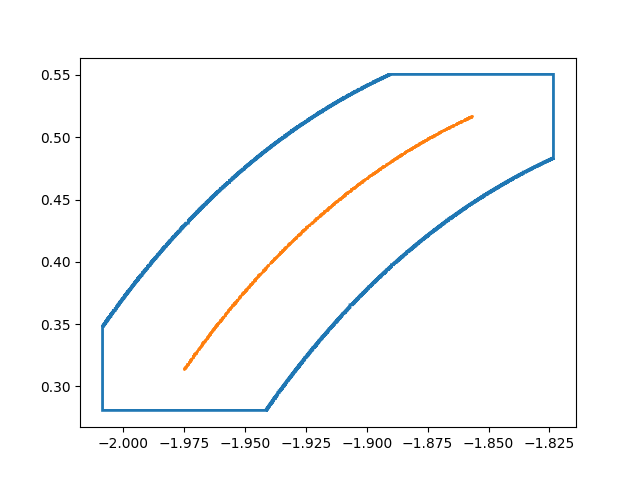

In [6]:
%matplotlib widget

fig, ax = plt.subplots()
ics = irx.utils.gen_ics(final_tm.domain, 1000)
# print(final_tm.domain @ jnp.vstack(jnp.linspace(0,1,100)))
# ics = irx.interval(jnp.zeros((100, 2)), final_tm.domain[None,:] @ jnp.vstack(jnp.linspace(0,1,100)))
hulls = jax.vmap(final_tm.evaluate)(ics)
irx.utils.draw_iarrays(ax, hulls)

centers = jax.vmap(final_tm.evaluate_polynomial)(ics)
ax.scatter(centers[:,0], centers[:,1], s=1)

'MultiPolygon' object has no attribute 'exterior'
(100, 141, 2)


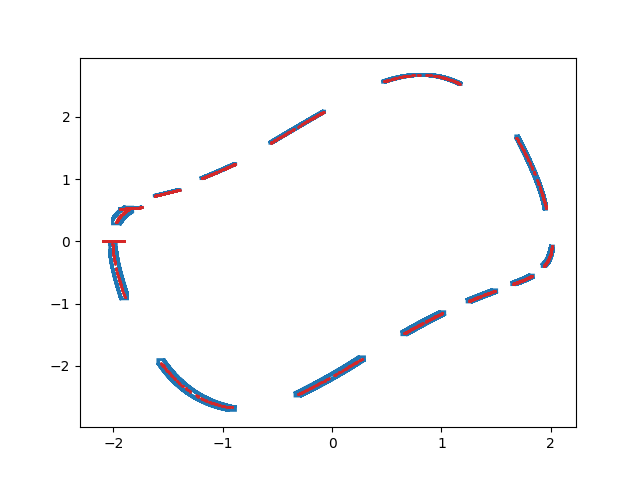

In [7]:
%matplotlib widget

fig, ax = plt.subplots()

mc_x0s = irx.utils.gen_ics(ix0, 100)
mc_trajs = jax.vmap(mc_sim)(mc_x0s)

PLOT_EVERY = 10
test_times = jnp.arange(t0, tf + dt, dt)[::PLOT_EVERY]
# irx.utils.draw_iarray(ax, tmx.interval_hull(), color="tab:red")

# irx.utils.draw_iarrays(ax, hulls[:fp.nsteps//2])
# irx.utils.draw_iarrays(ax, hulls[fp.nsteps//2:])

for t in test_times:
    spatial_tm = fp(t)
    # irx.utils.draw_iarray(ax, spatial_tm.interval_hull(), color="tab:blue")
    ics = irx.utils.gen_ics(spatial_tm.domain, 1000)
    hulls = jax.vmap(spatial_tm.evaluate)(ics)
    # centers = jax.vmap(final_tm.evaluate_polynomial)(ics)
    try :
        irx.utils.draw_iarrays(ax, hulls)
        # ax.scatter(centers[:,0], centers[:,1], s=1)
    except Exception as e :
        print(e)

mc_trajs = mc_trajs.to_convenience()
print(mc_trajs.ys.shape)
ax.scatter(
    mc_trajs.ys[:, ::PLOT_EVERY, 0],
    mc_trajs.ys[:, ::PLOT_EVERY, 1],
    color="tab:red",
    s=1,
)

plt.show()

